# Exploration des données - Analyse de sentiment (Sentiment140)

Exploration, analyse statistique et textuelle, preprocessing et préparation des données pour la classification binaire de sentiment sur Sentiment140 (1,6 million de tweets).

**Dataset :** Sentiment140 - `training.1600000.processed.noemoticon.csv`  
**Cible :** négatif (0) / positif (1)

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")

## 1. Chargement des données

Sentiment140 : 1,6 million de tweets annotés automatiquement via emoticônes (0 = négatif, 4 = positif).

Colonnes : `target`, `id`, `date`, `flag`, `user`, `text`.

In [2]:
DATA_PATH = "../training.1600000.processed.noemoticon.csv"
COLUMN_NAMES = ["target", "id", "date", "flag", "user", "text"]

df = pd.read_csv(DATA_PATH, encoding="latin-1", header=None, names=COLUMN_NAMES)

# Recodage 4 -> 1 pour avoir une cible binaire 0/1
df["target"] = df["target"].map({0: 0, 4: 1})

print("Dimensions du dataset :", df.shape)

Dimensions du dataset : (1600000, 6)


In [3]:
df.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   id      1600000 non-null  int64 
 2   date    1600000 non-null  object
 3   flag    1600000 non-null  object
 4   user    1600000 non-null  object
 5   text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [5]:
print("Types des colonnes :")
print(df.dtypes)
print()
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

Types des colonnes :
target     int64
id         int64
date      object
flag      object
user      object
text      object
dtype: object

Valeurs manquantes par colonne :
target    0
id        0
date      0
flag      0
user      0
text      0
dtype: int64


## 2. Analyse statistique

### 2.1 Distribution des labels

Distribution des labels :
target
Negatif (0)    800000
Positif (1)    800000
Name: count, dtype: int64

Proportion :
target
Negatif (0)    50.0 %
Positif (1)    50.0 %
Name: count, dtype: object


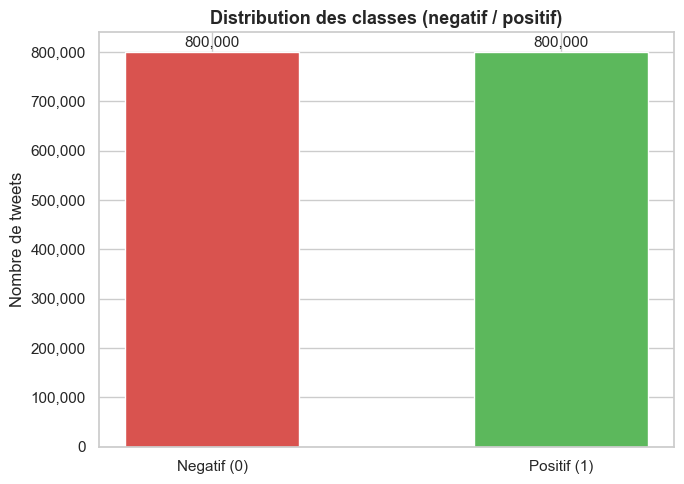

In [6]:
label_counts = df["target"].value_counts().sort_index()
label_names = {0: "Négatif (0)", 1: "Positif (1)"}

print("Distribution des labels :")
print(label_counts.rename(label_names))
print()
print("Proportion :")
print((label_counts / len(df) * 100).rename(label_names).round(2).astype(str) + " %")

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    [label_names[k] for k in label_counts.index],
    label_counts.values,
    color=["#d9534f", "#5cb85c"],
    edgecolor="white",
    width=0.5,
)
for bar, val in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5000,
            f"{val:,}", ha="center", va="bottom", fontsize=11)
ax.set_title("Distribution des classes (négatif / positif)", fontsize=13, fontweight="bold")
ax.set_ylabel("Nombre de tweets")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

### 2.2 Longueur des tweets (nombre de caractères)

Statistiques sur la longueur des tweets (caracteres) :
count    1600000.00
mean          74.09
std           36.44
min            6.00
25%           44.00
50%           69.00
75%          104.00
max          374.00
Name: tweet_length, dtype: float64

Moyenne  : 74.1 caracteres
Mediane  : 69.0 caracteres


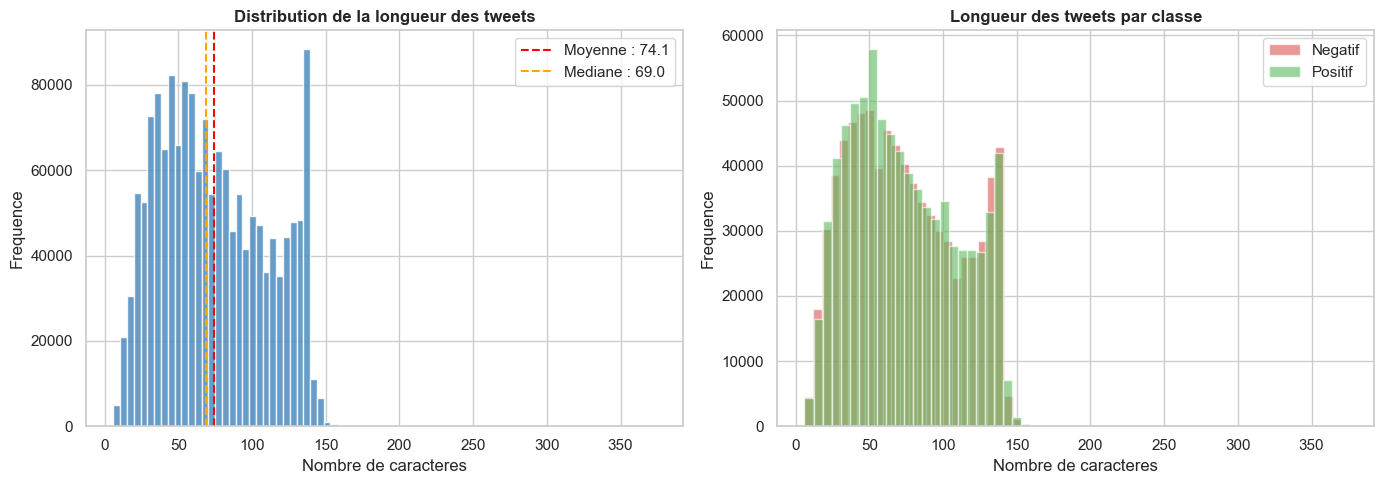

In [7]:
df["tweet_length"] = df["text"].str.len()

print("Statistiques sur la longueur des tweets (caractères) :")
print(df["tweet_length"].describe().round(2))
print()
print(f"Moyenne  : {df['tweet_length'].mean():.1f} caractères")
print(f"Médiane  : {df['tweet_length'].median():.1f} caractères")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["tweet_length"], bins=80, color="#4c8cbf", edgecolor="white", alpha=0.85)
axes[0].axvline(df["tweet_length"].mean(), color="red", linestyle="--", linewidth=1.5, label=f"Moyenne : {df['tweet_length'].mean():.1f}")
axes[0].axvline(df["tweet_length"].median(), color="orange", linestyle="--", linewidth=1.5, label=f"Médiane : {df['tweet_length'].median():.1f}")
axes[0].set_title("Distribution de la longueur des tweets", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Nombre de caractères")
axes[0].set_ylabel("Fréquence")
axes[0].legend()

for label, color, name in [(0, "#d9534f", "Négatif"), (1, "#5cb85c", "Positif")]:
    axes[1].hist(
        df[df["target"] == label]["tweet_length"],
        bins=60, alpha=0.6, color=color, label=name, edgecolor="white"
    )
axes[1].set_title("Longueur des tweets par classe", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Nombre de caractères")
axes[1].set_ylabel("Fréquence")
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.3 Nombre de mots par tweet

Statistiques sur le nombre de mots par tweet :
count    1600000.00
mean          13.18
std            6.96
min            1.00
25%            7.00
50%           12.00
75%           19.00
max           64.00
Name: word_count, dtype: float64

Moyenne  : 13.2 mots
Mediane  : 12.0 mots


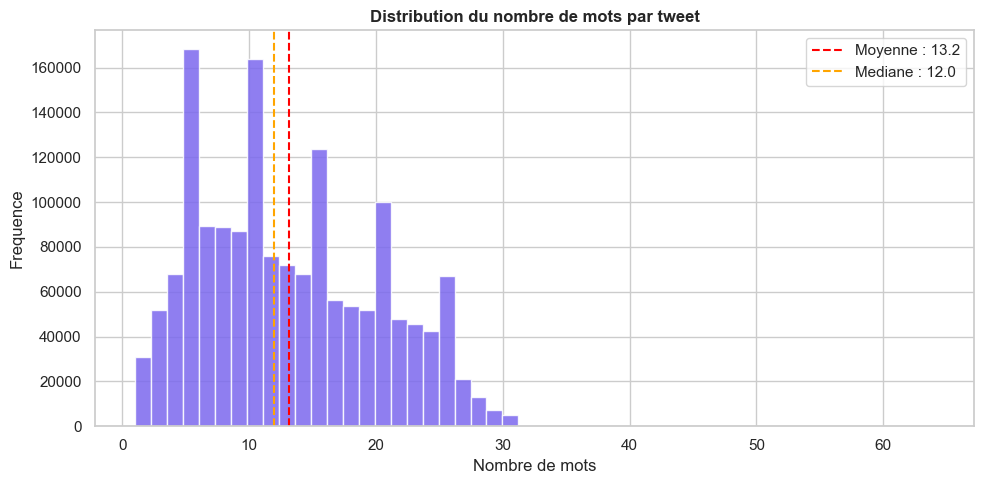

In [8]:
df["word_count"] = df["text"].str.split().str.len()

print("Statistiques sur le nombre de mots par tweet :")
print(df["word_count"].describe().round(2))
print()
print(f"Moyenne  : {df['word_count'].mean():.1f} mots")
print(f"Médiane  : {df['word_count'].median():.1f} mots")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["word_count"], bins=50, color="#7b68ee", edgecolor="white", alpha=0.85)
ax.axvline(df["word_count"].mean(), color="red", linestyle="--", linewidth=1.5,
           label=f"Moyenne : {df['word_count'].mean():.1f}")
ax.axvline(df["word_count"].median(), color="orange", linestyle="--", linewidth=1.5,
           label=f"Médiane : {df['word_count'].median():.1f}")
ax.set_title("Distribution du nombre de mots par tweet", fontsize=12, fontweight="bold")
ax.set_xlabel("Nombre de mots")
ax.set_ylabel("Fréquence")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Analyse textuelle

### 3.1 Mots les plus fréquents (texte brut)

Top 20 des mots dans le corpus brut, avant preprocessing.

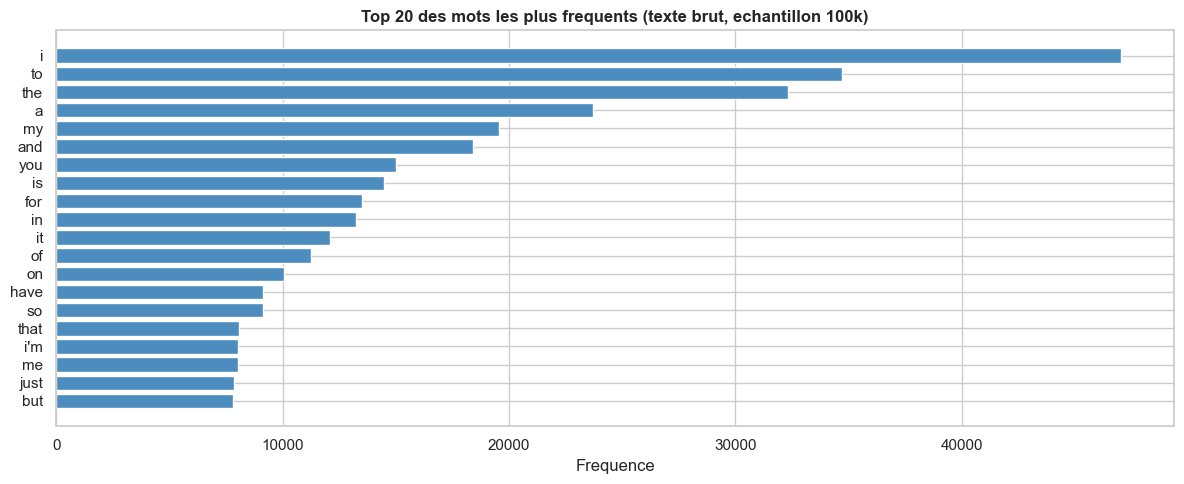

In [9]:
def top_words(series, n=20):
    """Retourne les n mots les plus fréquents dans une Series de textes."""
    all_words = " ".join(series.dropna()).lower().split()
    return Counter(all_words).most_common(n)

# Échantillon 100k pour limiter le coût mémoire/CPU
sample = df.sample(n=100_000, random_state=42)

top_raw = top_words(sample["text"], n=20)
words_raw, counts_raw = zip(*top_raw)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(words_raw[::-1], counts_raw[::-1], color="#4c8cbf", edgecolor="white")
ax.set_title("Top 20 des mots les plus fréquents (texte brut, échantillon 100k)", fontsize=12, fontweight="bold")
ax.set_xlabel("Fréquence")
plt.tight_layout()
plt.show()

### 3.2 WordCloud par classe

Nuages de mots pour les tweets négatifs et positifs (échantillon 100k).

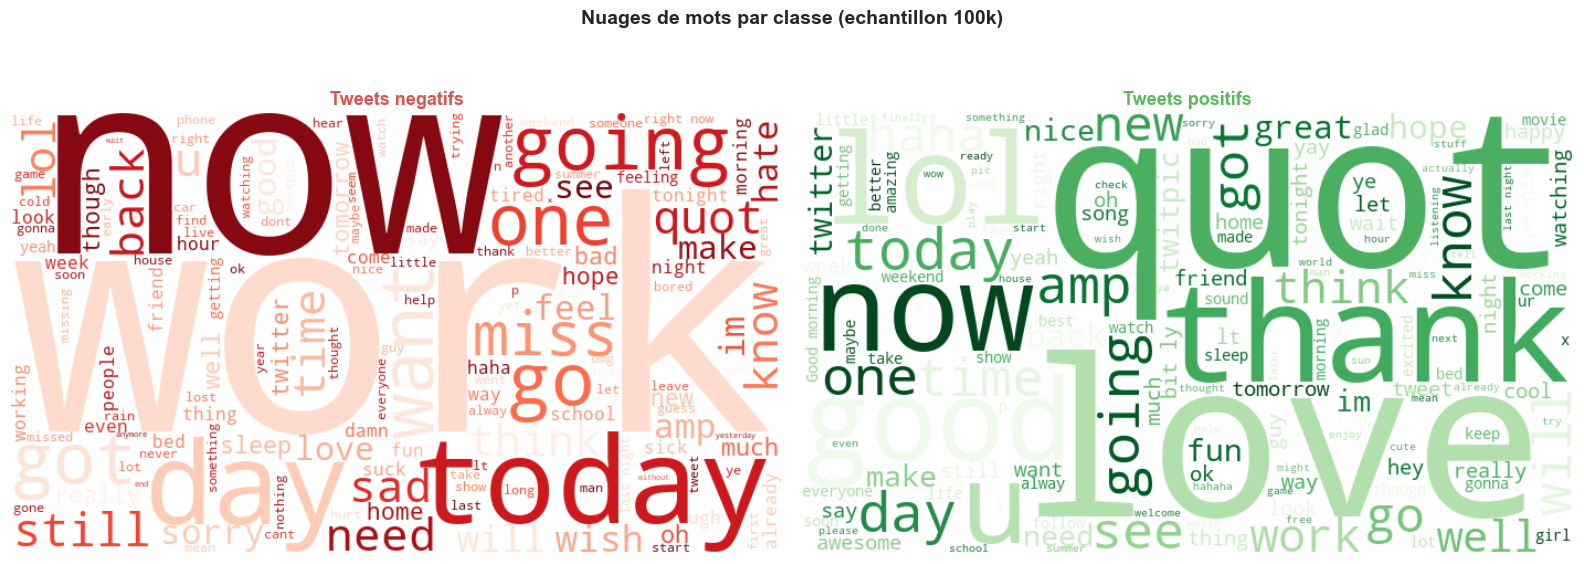

In [10]:
neg_text = " ".join(sample[sample["target"] == 0]["text"].dropna())
pos_text = " ".join(sample[sample["target"] == 1]["text"].dropna())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_neg = WordCloud(width=700, height=400, background_color="white",
                   colormap="Reds", max_words=150).generate(neg_text)
axes[0].imshow(wc_neg, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Tweets négatifs", fontsize=13, fontweight="bold", color="#d9534f")

wc_pos = WordCloud(width=700, height=400, background_color="white",
                   colormap="Greens", max_words=150).generate(pos_text)
axes[1].imshow(wc_pos, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Tweets positifs", fontsize=13, fontweight="bold", color="#5cb85c")

plt.suptitle("Nuages de mots par classe (échantillon 100k)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Exemples de tweets par classe

In [11]:
print("=== Exemples de tweets NÉGATIFS ===")
for tweet in df[df["target"] == 0]["text"].sample(5, random_state=42).values:
    print(f"  - {tweet}")

print()
print("=== Exemples de tweets POSITIFS ===")
for tweet in df[df["target"] == 1]["text"].sample(5, random_state=42).values:
    print(f"  - {tweet}")

=== Exemples de tweets NEGATIFS ===
  - @xnausikaax oh no! where did u order from? that's horrible 
  - A great hard training weekend is over.  a couple days of rest and lets do it again!  Lots of computer time to put in now 
  - Right, off to work  Only 5 hours to go until I'm free xD
  - I am craving for japanese food 
  - Jean Michel Jarre concert tomorrow  gotta work 7-3 before though 

=== Exemples de tweets POSITIFS ===
  - Is lookin 4ward to a long weekend  really dont want to go to work 2day tho =[ x
  - #myweakness  Is music and i live to meet the people who make it 
  - figured out the Internet on my new iPod 
  - @hillsongunited can't wait to worship with you guys tonight. it'll be so much fun 
  - @sillybeggar Congrats James !! I'm sure the book is going to be a huge success 


## 4. Preprocessing

`preprocess_text` (depuis `src.preprocessing`) :

1. Suppression des mentions (`@user`), URLs, hashtags et caractères spéciaux
2. Mise en minuscules
3. Tokenisation
4. Suppression des stopwords anglais (NLTK)
5. Lemmatisation (WordNetLemmatizer)

Renvoie une chaîne de tokens lemmatisés, prête pour la vectorisation.

In [12]:
from src.preprocessing import preprocess_text

print("Application du preprocessing sur l'ensemble du corpus...")
df["text_clean"] = df["text"].apply(preprocess_text)
print("Preprocessing terminé.")

Application du preprocessing sur l'ensemble du corpus...
Preprocessing termine.


### 4.1 Comparaison avant / après preprocessing

In [13]:
examples = df.sample(5, random_state=7)[["text", "text_clean"]].reset_index(drop=True)
examples.columns = ["Texte original", "Texte preprocessé"]
pd.set_option("display.max_colwidth", 120)
examples

,Texte original,Texte preprocesse
0,feelin down lately but i've no reason too,feelin lately ive reason
1,"With ju, clare, elly and zoe about to leave marbella",ju clare elly zoe leave marbella
2,Wish I couldve seen Miley and nick sing 2night.,wish couldve seen miley nick sing night
3,"Had to work today. 1 hour down, 6 to go.",work today hour go
4,Just started to catch up on House viewing. Kind of odd as I was watched blackadder the third last night. From George...,started catch house viewing kind odd watched blackadder third last night george house


### 4.2 Mots les plus fréquents après preprocessing

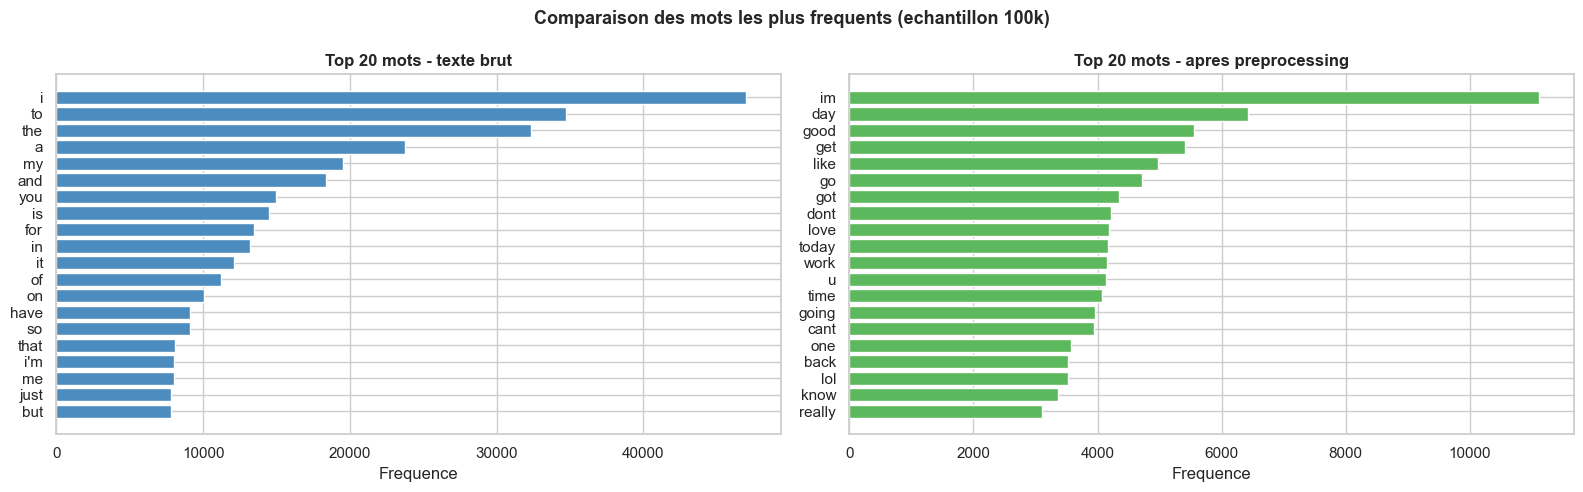

In [14]:
sample_clean = df.sample(n=100_000, random_state=42)

top_clean = top_words(sample_clean["text_clean"], n=20)
words_clean, counts_clean = zip(*top_clean)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(words_raw[::-1], counts_raw[::-1], color="#4c8cbf", edgecolor="white")
axes[0].set_title("Top 20 mots - texte brut", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Fréquence")

axes[1].barh(words_clean[::-1], counts_clean[::-1], color="#5cb85c", edgecolor="white")
axes[1].set_title("Top 20 mots - après preprocessing", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Fréquence")

plt.suptitle("Comparaison des mots les plus fréquents (échantillon 100k)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.3 Vérification : tweets vides après preprocessing

In [15]:
empty_after = df["text_clean"].str.strip().eq("").sum()
total = len(df)
print(f"Tweets vides après preprocessing : {empty_after:,} ({empty_after / total * 100:.2f} %)")

if empty_after > 0:
    print(f"Suppression des {empty_after} tweets vides...")
    df = df[df["text_clean"].str.strip() != ""].reset_index(drop=True)
    print(f"Taille du dataset après nettoyage : {len(df):,}")
else:
    print("Aucun tweet vide détecté.")

print()
print("Distribution des classes après nettoyage :")
print(df["target"].value_counts())

Tweets vides apres preprocessing : 7,519 (0.47 %)
Suppression des 7519 tweets vides...
Taille du dataset apres nettoyage : 1,592,481

Distribution des classes apres nettoyage :
target
0    796416
1    796065
Name: count, dtype: int64


## 5. Préparation des données

Split stratifié 80 / 10 / 10 sur la cible :

- **Train** : 80 % (entraînement)
- **Validation** : 10 % (sélection de modèle, hyperparamètres)
- **Test** : 10 % (évaluation finale, intouché pendant le développement)

`random_state=42` pour la reproductibilité. Les splits sont sauvegardés en CSV dans `data/`.

In [16]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

df_model = df[["target", "text", "text_clean"]].copy()

df_train, df_temp = train_test_split(
    df_model,
    test_size=0.20,
    stratify=df_model["target"],
    random_state=RANDOM_STATE,
)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    stratify=df_temp["target"],
    random_state=RANDOM_STATE,
)

print(f"Taille train      : {len(df_train):>10,} ({len(df_train)/len(df_model)*100:.1f} %)")
print(f"Taille validation : {len(df_val):>10,} ({len(df_val)/len(df_model)*100:.1f} %)")
print(f"Taille test       : {len(df_test):>10,} ({len(df_test)/len(df_model)*100:.1f} %)")

Taille train      :  1,273,984 (80.0 %)
Taille validation :    159,248 (10.0 %)
Taille test       :    159,249 (10.0 %)


### 5.1 Vérification de la stratification

Proportion de la classe positive (target=1) par split :
  Train        : 49.99 %
  Validation   : 49.99 %
  Test         : 49.99 %


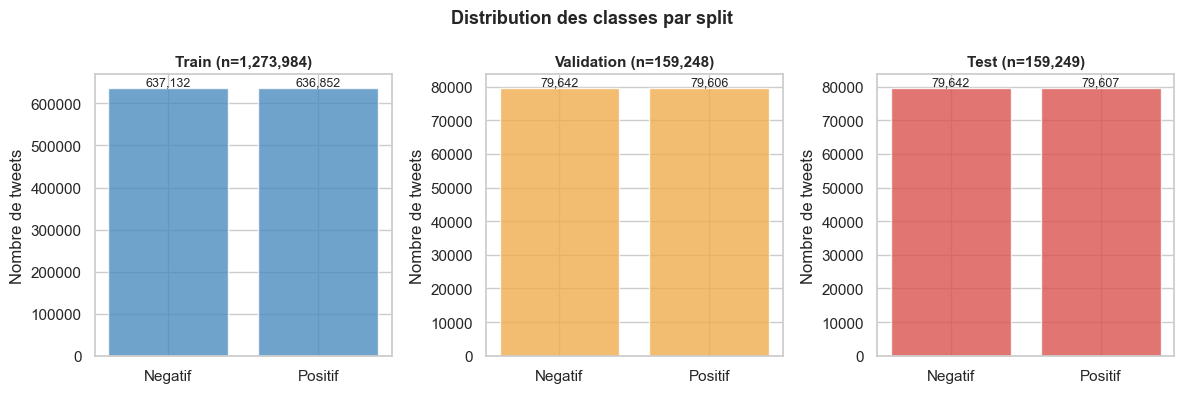

In [17]:
splits = {"Train": df_train, "Validation": df_val, "Test": df_test}

print("Proportion de la classe positive (target=1) par split :")
for name, split in splits.items():
    prop = split["target"].mean() * 100
    print(f"  {name:<12} : {prop:.2f} %")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = ["#4c8cbf", "#f0ad4e", "#d9534f"]

for ax, (name, split), color in zip(axes, splits.items(), colors):
    counts = split["target"].value_counts().sort_index()
    ax.bar(["Négatif", "Positif"], counts.values, color=color, alpha=0.8, edgecolor="white")
    ax.set_title(f"{name} (n={len(split):,})", fontsize=11, fontweight="bold")
    ax.set_ylabel("Nombre de tweets")
    for i, v in enumerate(counts.values):
        ax.text(i, v + len(split) * 0.005, f"{v:,}", ha="center", fontsize=9)

plt.suptitle("Distribution des classes par split", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 5.2 Sauvegarde des splits en CSV

In [18]:
import os

DATA_DIR = "../data"
os.makedirs(DATA_DIR, exist_ok=True)

output_files = {
    "train": df_train,
    "val": df_val,
    "test": df_test,
}

for split_name, split_df in output_files.items():
    path = os.path.join(DATA_DIR, f"{split_name}.csv")
    split_df.to_csv(path, index=False)
    print(f"Sauvegarde : {path}  ({len(split_df):,} lignes)")

print()
print("Splits sauvegardés dans", os.path.abspath(DATA_DIR))

Sauvegarde : ../data\train.csv  (1,273,984 lignes)
Sauvegarde : ../data\val.csv  (159,248 lignes)
Sauvegarde : ../data\test.csv  (159,249 lignes)

Splits sauvegardes avec succes dans d:\code\Projet7\data
